In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import random

## Loading dataset

In [2]:
dataset_name = 'mnist'

In [3]:
if dataset_name == 'mnist':
	(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
elif dataset_name == 'cifar10':
	(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step 


## Preprocessing data

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Exploring the data

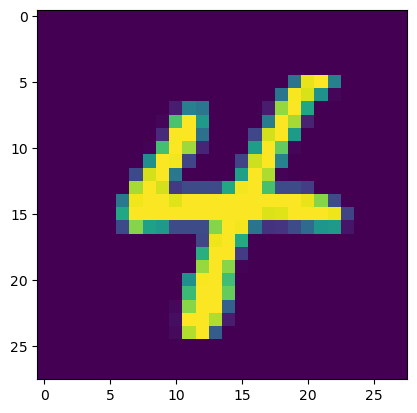

In [5]:
plt.imshow(random.choice(X_train))
plt.show()

In [6]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [7]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [8]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [9]:
y_train[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

## Defining the network

In [10]:
model = Sequential([
	Input(shape=(X_train.shape[1], X_train.shape[2])),
	Flatten(),
	Dense(128, activation='relu'),
	Dropout(0.2),
	Dense(64, activation='relu'),
	Dropout(0.2),
	Dense(10, activation='softmax')
])

## Training the model

In [11]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.7369 - loss: 0.8561 - val_accuracy: 0.9042 - val_loss: 0.3426
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8775 - loss: 0.4166 - val_accuracy: 0.9253 - val_loss: 0.2564
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9022 - loss: 0.3345 - val_accuracy: 0.9370 - val_loss: 0.2165
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9155 - loss: 0.2861 - val_accuracy: 0.9431 - val_loss: 0.1925
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9250 - loss: 0.2560 - val_accuracy: 0.9486 - val_loss: 0.1701
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - accuracy: 0.9320 - loss: 0.2316 - val_accuracy: 0.9533 - val_loss: 0.1563
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 15ms/step - accuracy: 0.9376 - loss: 0.2124 - val_accuracy: 0.9563 - val_loss: 0.1460
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9416 -

## Plotting loss and accuracy

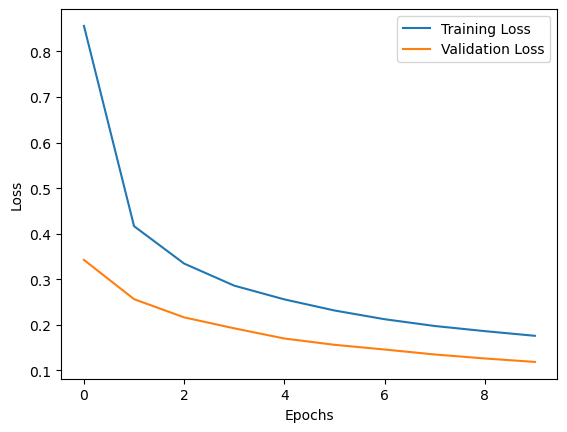

In [13]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

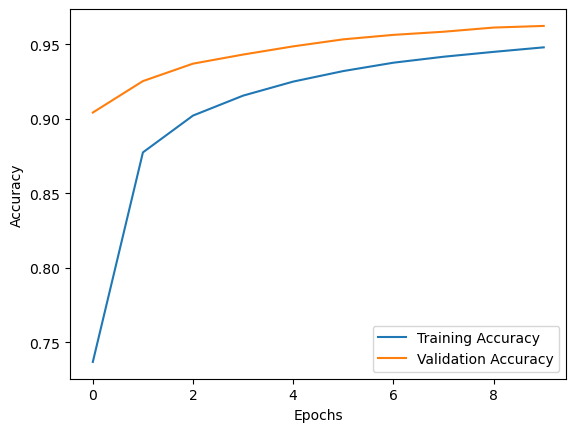

In [14]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9623 - loss: 0.1187


## Predicitons

In [16]:
y_preds = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


Actual label: 1
Predicted label: 1


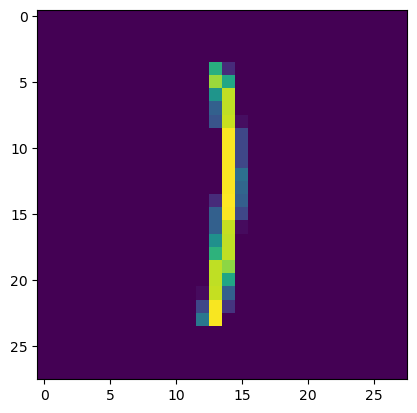

In [17]:
plt.imshow(X_test[40])
print(f'Actual label: {np.argmax(y_test[40])}')
print(f'Predicted label: {np.argmax(y_preds[40])}')
plt.show()